In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import scipy.sparse
import matplotlib.pyplot as plt

In [ ]:
X_train = np.load('./data/X_train_seq.npy')
y_train = np.load('./data/y_train_seq.npy')
X_test = np.load('./data/X_test_seq.npy', )
y_test = np.load('./data/y_test_seq.npy')

In [5]:
import pytorch_lightning as pl
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim import RMSprop
from torch import nn, concat, Generator
from torchinfo import summary
from pytorch_lightning.utilities import rank_zero_only
from pytorch_lightning.callbacks import Callback
from torchmetrics import (MeanAbsoluteError,
                          R2Score,
                          Accuracy,
                          MeanSquaredError)

Set number of cores to use for general pytorch processes (this does not influence Trainer objects)

In [6]:
torch.set_num_threads(6)  # Set to # cores used
torch.set_num_interop_threads(6)  # Controls how many threads PyTorch launches for inter-op parallelism
print(torch.get_num_threads())

6


# LSTM Model

### Class definitions

In [7]:
class BasicDataModule(pl.LightningDataModule):
    def __init__(self, X_train, y_train, X_test=None, y_test=None, batch_size=32, num_workers=0, validation=0.2, seed=0, persistent_workers=True):
        super(BasicDataModule, self).__init__()

        self.batch_size = batch_size
        self.num_workers = num_workers
        self.persistent_workers = persistent_workers and num_workers > 0

        full_dataset = TensorDataset(X_train, y_train)

        val_size = int(len(full_dataset) * validation) if isinstance(validation, float) else validation
        train_size = len(full_dataset) - val_size

        self.train_dataset, self.validation_dataset = random_split(
            full_dataset, [train_size, val_size]
        )

        if X_test is not None and y_test is not None:
            self.test_dataset = TensorDataset(X_test, y_test)
        else:
            self.test_dataset = None

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, persistent_workers=self.persistent_workers)

    def val_dataloader(self):
        return DataLoader(self.validation_dataset, batch_size=self.batch_size, num_workers=self.num_workers, persistent_workers=self.persistent_workers)

    def test_dataloader(self):
        if self.test_dataset is None:
            return None
        return DataLoader(self.test_dataset, batch_size=self.batch_size, num_workers=self.num_workers, persistent_workers=self.persistent_workers)

In [8]:
class BasicModule(pl.LightningModule):
    def __init__(self, model, loss, optimizer=None, metrics=None, on_epoch=True, pre_process_y_for_metrics=lambda y: y):

        super(BasicModule, self).__init__()

        self.model = model
        self.loss = loss

        optimizer = optimizer or RMSprop(model.parameters())
        self._optimizer = optimizer
        self.metrics = metrics
        self.on_epoch = on_epoch
        self.pre_process_y_for_metrics = pre_process_y_for_metrics
        
    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self.forward(x)
        loss = self.loss(preds, y)
        self.log("train_loss", loss, on_epoch=self.on_epoch, on_step=False)

        y_ = self.pre_process_y_for_metrics(y)
        for _metric in self.metrics.keys():
            pl_metric = self.metrics[_metric]
            self.log(f"train_{_metric}", pl_metric(preds.to(pl_metric.device), y_.to(pl_metric.device)), on_epoch=self.on_epoch)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch

    @rank_zero_only
    def validation_step(self, batch, batch_idx):
        x, y = batch

    def predict_step(self, batch, batch_idx):
        x, y = batch
        return y, self.forward(x)

    def configure_optimizers(self):
        return self._optimizer

    @staticmethod
    def regression(model, metrics=None, device='cpu', **kwargs):

        if metrics is None:
            metrics = {}

        loss = nn.MSELoss().to(device)
        if device is not None:
            for key, metric in metrics.items():
                metrics[key] = metric.to(device)
        return BasicModule(model, loss, metrics=metrics, **kwargs)

    @staticmethod
    def binary_classification(model, metrics=None, device='cpu', **kwargs):

        if metrics is None:
            metrics = {}

        loss = nn.BCEWithLogitsLoss()
        if 'accuracy' not in metrics:
            metrics['accuracy'] = Accuracy('binary')
        if device is not None:
            for key, metric in metrics.items():
                metrics[key] = metric.to(device)
        return BasicModule(model, loss, metrics=metrics, pre_process_y_for_metrics = lambda x: x.int(), **kwargs)

    @staticmethod
    def classification(model, num_classes, metrics=None, device='cpu', **kwargs):
        if metrics is None:
            metrics = {}
        loss = nn.CrossEntropyLoss().to(device)
        if 'accuracy' not in metrics:
            metrics['accuracy'] = Accuracy('multiclass', num_classes=num_classes)
        if device is not None:
            for key, metric in metrics.items():
                metrics[key] = metric.to(device)

        return BasicModule(model, loss, metrics=metrics, **kwargs)

In [9]:
class BasicErrorTracker(Callback):

    def on_validation_epoch_start(self, trainer, pl_module):
        self.val_preds = []
        self.val_targets = []

    def on_validation_batch_start(self, trainer, pl_module, batch, batch_idx, dataloader_idx=0):
        x, y = batch
        self.val_preds.append(pl_module.forward(x))
        self.val_targets.append(y)

    def on_validation_epoch_end(self, trainer, pl_module):
        preds = concat(self.val_preds)
        targets = concat(self.val_targets)
        targets_ = pl_module.pre_process_y_for_metrics(targets)

        loss = pl_module.loss(preds, targets)
        pl_module.log("valid_loss", loss, on_epoch=pl_module.on_epoch)

        for _metric in pl_module.metrics.keys():
            pl_metric = pl_module.metrics[_metric]
            pl_module.log(f"valid_{_metric}",
                          pl_metric(preds.to(pl_metric.device), targets_.to(pl_metric.device)),
                          on_epoch=pl_module.on_epoch)

    def on_test_epoch_start(self, trainer, pl_module):
        self.test_preds = []
        self.test_targets = []

    def on_test_batch_start(self, trainer, pl_module, batch, batch_idx, dataloader_idx=0):
        x, y = batch
        self.test_preds.append(pl_module.forward(x))
        self.test_targets.append(y)

    def on_test_epoch_end(self, trainer, pl_module):
        preds = concat(self.test_preds)
        targets = concat(self.test_targets)
        targets_ = pl_module.pre_process_y_for_metrics(targets)
        
        loss = pl_module.loss(preds, targets)
        pl_module.log("test_loss", loss, on_epoch=pl_module.on_epoch)

        for _metric in pl_module.metrics.keys():
            pl_metric = pl_module.metrics[_metric]
            pl_module.log(f"test_{_metric}",
                          pl_metric(preds.to(pl_metric.device), targets_.to(pl_metric.device)),
                          on_epoch=pl_module.on_epoch)

### Convert data to tensor

In [10]:
X_train_tensor = torch.tensor(X_train).long()
del X_train
y_train_tensor = torch.tensor(y_train).long()
del y_train
X_test_tensor = torch.tensor(X_test).long()
del X_test
y_test_tensor = torch.tensor(y_test).long()
del y_test

In [11]:
lstm_dm = BasicDataModule(
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    X_test=X_test_tensor,
    y_test=y_test_tensor,
    validation=0.2,
    num_workers=6, # num_workers up to number of CPU cores used
    batch_size=32 # try 16 or lower for less memory usage
) 

## Model with Custom Embedding

In [ ]:
class LSTMmodel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=64, output_dim=5):
        super(LSTMmodel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, dropout = 0.3, num_layers=2, bidirectional=True, batch_first=True)
        self.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden_dim * 2, output_dim)) # *2 for bidirectional

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        hidden = lstm_out[:, -1, :]  # use last hidden state of sequence; dim of lstm_out is [batch_size x sequence_length x hidden_dim]
        logits = self.fc(hidden)
        return logits


Define a model module

Report model summary (parameters to estimate)

In [13]:
lstm_model = LSTMmodel(10001, embedding_dim=128, hidden_dim=64, output_dim=5)

summary(lstm_model, input_data=X_train_tensor[:5], col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
LSTMmodel                                [5, 50]                   [5, 5]                    --
├─Embedding: 1-1                         [5, 50]                   [5, 50, 128]              1,280,128
├─LSTM: 1-2                              [5, 50, 128]              [5, 50, 128]              198,656
├─Sequential: 1-3                        [5, 128]                  [5, 5]                    --
│    └─Dropout: 2-1                      [5, 128]                  [5, 128]                  --
│    └─Linear: 2-2                       [5, 128]                  [5, 5]                    645
Total params: 1,479,429
Trainable params: 1,479,429
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 56.07
Input size (MB): 75.09
Forward/backward pass size (MB): 0.51
Params size (MB): 5.92
Estimated Total Size (MB): 81.52

### Training

In [15]:
lstm_optimizer = RMSprop(lstm_model.parameters(), lr=0.001)
lstm_module = BasicModule.classification(model=lstm_model, num_classes=5, optimizer=lstm_optimizer)

`wyoming.csv` ~1.5m per epoch (Apple M2 w/ 8 GB RAM)

`pl.Trainer(accelerator='cpu', devices=8 ...)` is much slower than the default `'mps'` for Apple chips, even when multiple cores used.

In [ ]:
lstm_logger = pl.loggers.CSVLogger('logs', name='lstm')
lstm_trainer = pl.Trainer(deterministic=True, logger=lstm_logger, max_epochs=8, callbacks=[BasicErrorTracker()])
lstm_trainer.fit(lstm_module, datamodule=lstm_dm)

In [ ]:
test_results = lstm_trainer.test(lstm_module, datamodule=lstm_dm)

In [32]:
# Function to plot CSVlogger results (from Introduction to Statistical Learning) 
def summary_plot(results, ax, col='loss', valid_legend='Validation', training_legend='Training', ylabel='Loss', fontsize=20):
    for (column, color, label) in zip([f'train_{col}_epoch', f'valid_{col}'], ['black', 'red'], [training_legend, valid_legend]):
        results.plot(x='epoch',
                     y=column,
                     label=label,
                     marker='o',
                     color=color,
                     ax=ax)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    return ax

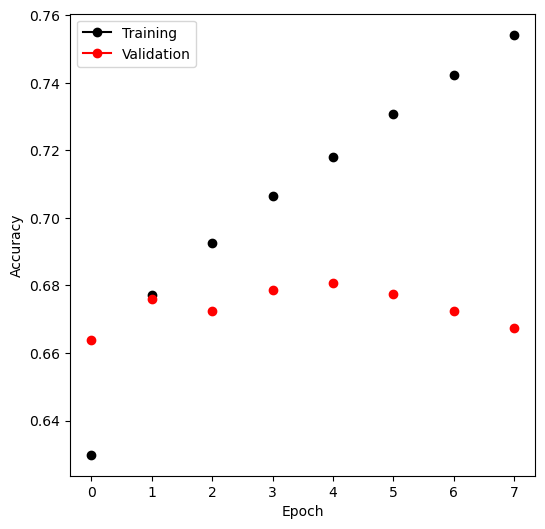

In [20]:
lstm_results = pd.read_csv(lstm_logger.experiment.metrics_file_path)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
summary_plot(lstm_results, ax, col='accuracy', ylabel='Accuracy')
plt.show()

## Model with Custom Embedding and Attention

In [14]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        attn_weights = torch.softmax(self.attn(lstm_out), dim=1)  # Compute attention scores
        context = torch.sum(attn_weights * lstm_out, dim=1)  # Weighted sum of LSTM outputs
        return context

class LSTMAttentionModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=64, output_dim=5, num_layers=2, bidirectional=True, dropout=0.3):
        super(LSTMAttentionModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, bidirectional=bidirectional, batch_first=True, dropout=dropout)
        
        self.attention = Attention(hidden_dim * 2 if bidirectional else hidden_dim)

        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        )

    def forward(self, x):
        embedded = self.embedding(x)  # Shape: (batch_size, seq_len, embedding_dim)
        lstm_out, _ = self.lstm(embedded)  # Shape: (batch_size, seq_len, hidden_dim * num_directions)
        context_vector = self.attention(lstm_out)  # Shape: (batch_size, seq_len), so reduces hidden_dim*2 down to 1, so 1 weight per word
        logits = self.fc(context_vector)  # Shape: (batch_size, output_dim)
        return logits


Define a model module

Report model summary (parameters to estimate)

In [15]:
# Changed hidden_dim=128 from 64 - does not improve accuracy
lstmAttn_model = LSTMAttentionModel(10001, embedding_dim=128, hidden_dim=64, output_dim=5, num_layers=2, bidirectional=True, dropout=0.3)

summary(lstmAttn_model, input_data=X_train_tensor[:5], col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
LSTMAttentionModel                       [5, 50]                   [5, 5]                    --
├─Embedding: 1-1                         [5, 50]                   [5, 50, 128]              1,280,128
├─LSTM: 1-2                              [5, 50, 128]              [5, 50, 128]              198,656
├─Attention: 1-3                         [5, 50, 128]              [5, 128]                  --
│    └─Linear: 2-1                       [5, 50, 128]              [5, 50, 1]                129
├─Sequential: 1-4                        [5, 128]                  [5, 5]                    --
│    └─Dropout: 2-2                      [5, 128]                  [5, 128]                  --
│    └─Linear: 2-3                       [5, 128]                  [5, 5]                    645
Total params: 1,479,558
Trainable params: 1,479,558
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 56.07


### Training with Attention

In [34]:
lstmAttn_optimizer = RMSprop(lstmAttn_model.parameters(), lr=0.001)
lstmAttn_module = BasicModule.classification(model=lstmAttn_model, num_classes=5, optimizer=lstmAttn_optimizer)

`wyoming.csv` ~2.5m per epoch (Apple M2 w/ 8 GB RAM)

In [ ]:
lstmAttn_logger = pl.loggers.CSVLogger('logs', name='lstmAttn')
lstmAttn_trainer = pl.Trainer(deterministic=True, logger=lstmAttn_logger, max_epochs=10, callbacks=[BasicErrorTracker()])
lstmAttn_trainer.fit(lstmAttn_module, datamodule=lstm_dm) # dm is same as last time

In [ ]:
test_results_attn = lstmAttn_trainer.test(lstmAttn_module, datamodule=lstm_dm)

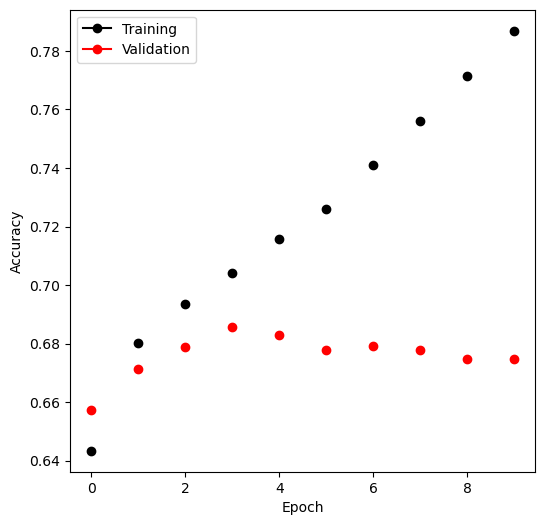

In [37]:
lstmAttn_results = pd.read_csv(lstmAttn_logger.experiment.metrics_file_path)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
summary_plot(lstmAttn_results, ax, col='accuracy', ylabel='Accuracy')
plt.show()

## Model with GloVe Embedding Layer

In [ ]:
class LSTMGloveModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=64, output_dim=5):
        super(LSTMGloveModel, self).__init__()

        vocab_size, embedding_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=True  # Set to True to avoid fine-tuning
        )

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, dropout=0.3,
                            num_layers=2, bidirectional=True, batch_first=True)

        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_dim * 2, output_dim)  # *2 for bidirectional
        )

    def forward(self, x):
        embedded = self.embedding(x)              # [batch_size, seq_len, embedding_dim]
        lstm_out, _ = self.lstm(embedded)         # [batch_size, seq_len, hidden_dim * 2]
        hidden = lstm_out[:, -1, :]               # [batch_size, hidden_dim * 2]
        logits = self.fc(hidden)                  # [batch_size, output_dim]
        return logits


In [18]:
embedding_matrix = np.load('data/glove_embedding_matrix.npy')

Define a model module

Report model summary (parameters to estimate)

In [26]:
lstmGlove_model = LSTMGloveModel(embedding_matrix, hidden_dim=64, output_dim=5)

summary(lstmGlove_model, input_data=X_train_tensor[:5], col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
LSTMGloveModel                           [5, 50]                   [5, 5]                    --
├─Embedding: 1-1                         [5, 50]                   [5, 50, 50]               2,683,400
├─LSTM: 1-2                              [5, 50, 50]               [5, 50, 128]              158,720
├─Sequential: 1-3                        [5, 128]                  [5, 5]                    --
│    └─Dropout: 2-1                      [5, 128]                  [5, 128]                  --
│    └─Linear: 2-2                       [5, 128]                  [5, 5]                    645
Total params: 2,842,765
Trainable params: 2,842,765
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 53.10
Input size (MB): 75.09
Forward/backward pass size (MB): 0.36
Params size (MB): 11.37
Estimated Total Size (MB): 86.82

### Training with Glove

In [27]:
lstmGlove_optimizer = RMSprop(lstmGlove_model.parameters(), lr=0.001)
lstmGlove_module = BasicModule.classification(model=lstmGlove_model, num_classes=5, optimizer=lstmGlove_optimizer)

In [28]:
lstmGlove_logger = pl.loggers.CSVLogger('logs', name='lstmGlove')
lstmGlove_trainer = pl.Trainer(deterministic=True, logger=lstmGlove_logger, max_epochs=10, callbacks=[BasicErrorTracker()])
lstmGlove_trainer.fit(lstmGlove_module, datamodule=lstm_dm) # dm is same as last time

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | LSTMGloveModel   | 2.8 M  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
2.8 M     Trainable params
0         Non-trainable params
2.8 M     Total params
11.371    Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [30]:
test_results_glove = lstmGlove_trainer.test(lstmGlove_module, datamodule=lstm_dm)

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6782297492027283     │
│         test_loss         │    0.8200651407241821     │
└───────────────────────────┴───────────────────────────┘

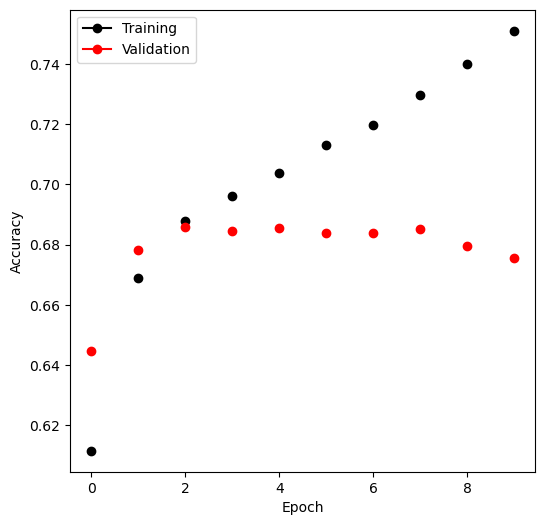

In [33]:
lstmGlove_results = pd.read_csv(lstmGlove_logger.experiment.metrics_file_path)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
summary_plot(lstmGlove_results, ax, col='accuracy', ylabel='Accuracy')
plt.show()